# Предсказание рейтинга фильма на основе характеристик

> **Датасет:** Full TMDB Movies Dataset 2024 (1M Movies)  
> **Задача:** регрессия — предсказать зрительский рейтинг фильма (`vote_average`)  
> **Методы:** K-Means кластеризация, Linear Regression, Random Forest, Gradient Boosting, CatBoost

---

## 1. Подготовка среды

### 1.1 Импорт библиотек

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Библиотеки загружены успешно")

Библиотеки загружены успешно


### 1.2 Настройка путей

In [ ]:
BASE_PATH = Path.cwd()
IMG_PATH = str(BASE_PATH / 'images') + '/'
DATA_PATH = str(BASE_PATH / 'data') + '/'

Path(IMG_PATH).mkdir(parents=True, exist_ok=True)

---

## 2. Загрузка данных

Загружаем случайную выборку 100 000 фильмов из датасета объёмом ~1 миллион записей. Используем `random_state=42` для воспроизводимости результатов.

In [3]:
df = pd.read_csv(f'{DATA_PATH}TMDB_movie_dataset_v11.csv').sample(n=100000, random_state=42)

# сбрасываем индексы после выборки
df = df.reset_index(drop = True)

print(f"Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов")

Датасет загружен: 100000 строк, 24 столбцов


### 2.1 Первичный осмотр

In [4]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,815449,Échate esta copa conmigo,5.0,1,Released,2013-12-31,0,0,False,NaN,...,Échate esta copa conmigo,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,769455,Dialog,0.0,0,Released,1997-01-01,0,5,False,NaN,...,Diyalog,Two firends having a chat about the meaningles...,0.6,NaN,NaN,Drama,NaN,NaN,Turkish,NaN
2,894624,Wild Alaska: Arctic Summer,0.0,0,Released,2019-06-25,0,44,False,NaN,...,Wild Alaska: Arctic Summer,The rugged coast of our biggest state harbors ...,0.6,/lBfgU9qD4yUtgL9NV0JrfaVXKBG.jpg,NaN,Documentary,NaN,NaN,English,NaN
3,518429,Entropia,8.0,1,Released,2017-09-15,0,15,False,NaN,...,Entropia,An aging woman attempts to regain her youth th...,0.6,/eDOFO76YJOvsMIDbmDyyQTsiVz5.jpg,NaN,Horror,NaN,United States of America,English,"witch, taxidermy, old woman"
4,514783,Carlos Kleiber - bei der Probe & in concert,0.0,0,Released,2003-03-17,0,0,False,NaN,...,Carlos Kleiber - bei der Probe & in concert,NaN,0.6,/iTPJ51BM4wSeMHmyOY849UmNUFW.jpg,NaN,Music,NaN,NaN,German,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    100000 non-null  int64  
 1   title                 99999 non-null   object 
 2   vote_average          100000 non-null  float64
 3   vote_count            100000 non-null  int64  
 4   status                100000 non-null  object 
 5   release_date          78001 non-null   object 
 6   revenue               100000 non-null  int64  
 7   runtime               100000 non-null  int64  
 8   adult                 100000 non-null  bool   
 9   backdrop_path         24975 non-null   object 
 10  budget                100000 non-null  int64  
 11  homepage              10268 non-null   object 
 12  imdb_id               47291 non-null   object 
 13  original_language     100000 non-null  object 
 14  original_title        99999 non-null   object 
 15  o

In [6]:
df.describe().round(2)

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,100000.00,100000.00,100000.00,1.000000e+05,100000.00,1.000000e+05,100000.00
mean,895949.55,1.55,14.75,5.692931e+05,44.08,2.303653e+05,1.04
std,475376.94,2.85,273.37,1.589522e+07,55.98,4.714701e+06,10.92
min,19.00,0.00,0.00,0.000000e+00,0.00,0.000000e+00,0.00
25%,493750.75,0.00,0.00,0.000000e+00,0.00,0.000000e+00,0.04
50%,921247.00,0.00,0.00,0.000000e+00,16.00,0.000000e+00,0.60
75%,1312515.75,1.00,1.00,0.000000e+00,85.00,0.000000e+00,0.71
max,1678037.00,10.00,24649.00,1.428545e+09,2009.00,5.000000e+08,2994.36


### 2.2 Анализ пропущенных значений

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Пропусков': missing,
    '% от всего': missing_pct
}).sort_values('Пропусков', ascending=False)

print(missing_df[missing_df['Пропусков'] > 0])

                      Пропусков  % от всего
homepage                  89732       89.73
tagline                   86307       86.31
keywords                  75434       75.43
backdrop_path             75025       75.02
production_companies      57424       57.42
imdb_id                   52709       52.71
production_countries      48186       48.19
spoken_languages          46252       46.25
genres                    43808       43.81
poster_path               35377       35.38
overview                  22942       22.94
release_date              21999       22.00
title                         1        0.00
original_title                1        0.00


---

## 3. Предобработка данных

### 3.1 Удаление ненужных столбцов

Удаляем мета-колонки, которые не несут информации для модели: ссылки на изображения, описания, идентификаторы.

In [8]:
cols_to_drop = [
    'id', 'adult', 'original_title',
    'backdrop_path', 'homepage', 'imdb_id', 'overview',
    'poster_path', 'tagline', 'production_companies',
    'production_countries', 'spoken_languages', 'keywords'
]
df = df.drop(columns=cols_to_drop)

print(f"Осталось колонок: {df.shape[1]}")
print(df.columns.tolist())

Осталось колонок: 11
['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'original_language', 'popularity', 'genres']


### 3.2 Фильтрация строк

Удаляем фильмы без даты выхода, с нулевым рейтингом или менее 3 оценок — такие записи не несут достоверной информации.

In [9]:
df = df.dropna(subset=['release_date'])

df = df[df['vote_average'] > 0]
df = df[df['vote_count'] >= 3]

print(f"Строк после фильтрации: {len(df)}")

Строк после фильтрации: 12297


### 3.3 Заполнение пропусков

In [10]:
# заполняем пропуски в жанрах

df['genres'] = df['genres'].fillna('Unknown')

In [11]:
# заполняем пропуски в числовых колонках

# бюджет и сборы — заполняем нулями (фильм может не иметь данных)
df['budget'] = pd.to_numeric(df['budget'], errors='coerce').fillna(0)
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce').fillna(df['runtime'].median())

print("Пропуски после чистки:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Пропуски после чистки:
Series([], dtype: int64)


### 3.4 Итог предобработки

In [12]:
print(f"Итоговый датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head(3)

Итоговый датасет: 12297 строк, 11 колонок


,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,original_language,popularity,genres
12,Teacher Somsri,3.6,6,Released,1985-01-11,0,117,0,th,0.600,"Drama, History"
35,The Bolinhas 2 - A Bigger Fight,9.7,3,Released,2020-08-11,0,0,0,pt,0.600,"Animation, Adventure, Fantasy, Action"
45,Melody Hina Marks Debut! This Scandinavian Blo...,9.3,3,Released,2019-12-06,0,134,0,ja,47.902,Documentary


In [13]:
print(df.shape)
print(df.columns.tolist())

(12297, 11)
['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'original_language', 'popularity', 'genres']


---

## 4. Разведочный анализ данных (EDA)

### 4.1 Распределение целевой переменной

Анализируем распределение зрительского рейтинга `vote_average`.

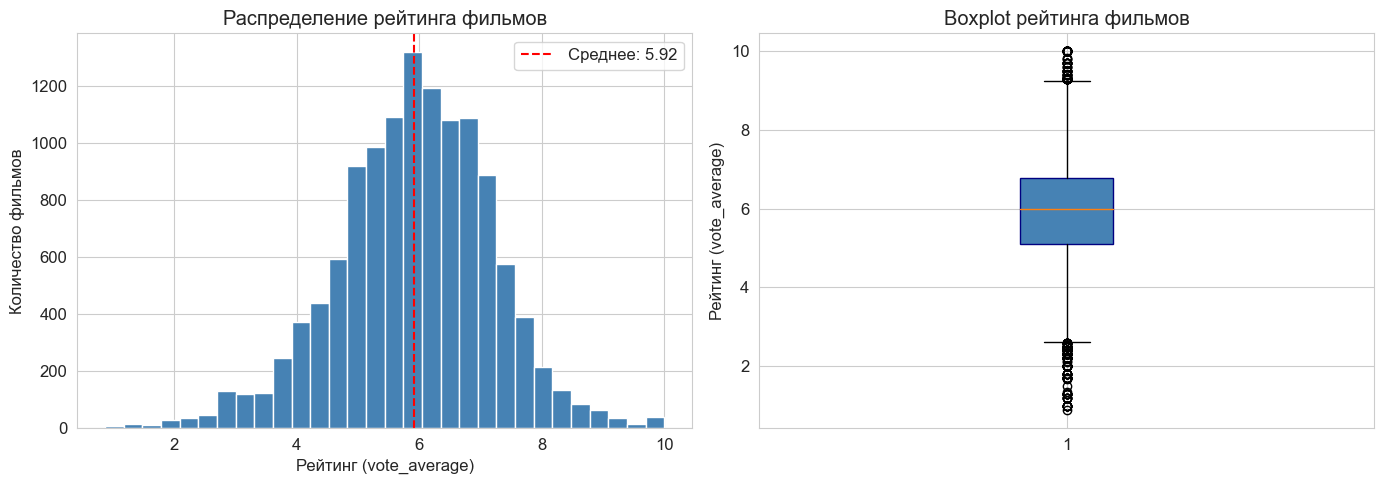

Среднее:          5.92
Медиана:          6.00
Стд. отклонение:  1.27
Мин: 0.88  Макс: 10.00


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# гистограмма
axes[0].hist(df['vote_average'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение рейтинга фильмов')
axes[0].set_xlabel('Рейтинг (vote_average)')
axes[0].set_ylabel('Количество фильмов')
axes[0].axvline(df['vote_average'].mean(), color='red', linestyle='--',
                label=f"Среднее: {df['vote_average'].mean():.2f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['vote_average'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot рейтинга фильмов')
axes[1].set_ylabel('Рейтинг (vote_average)')

plt.tight_layout()
plt.savefig(f'{IMG_PATH}01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Среднее:          {df['vote_average'].mean():.2f}")
print(f"Медиана:          {df['vote_average'].median():.2f}")
print(f"Стд. отклонение:  {df['vote_average'].std():.2f}")
print(f"Мин: {df['vote_average'].min():.2f}  Макс: {df['vote_average'].max():.2f}")

### 4.2 Корреляционная матрица

Оцениваем линейные связи между числовыми признаками и целевой переменной.

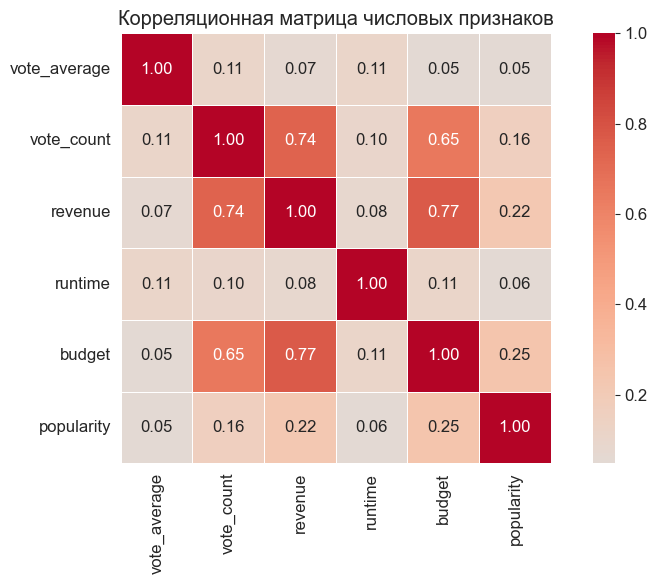

In [15]:
numeric_cols = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig(f'{IMG_PATH}02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Средний рейтинг по жанрам

Проверяем гипотезу: жанр статистически влияет на зрительский рейтинг.

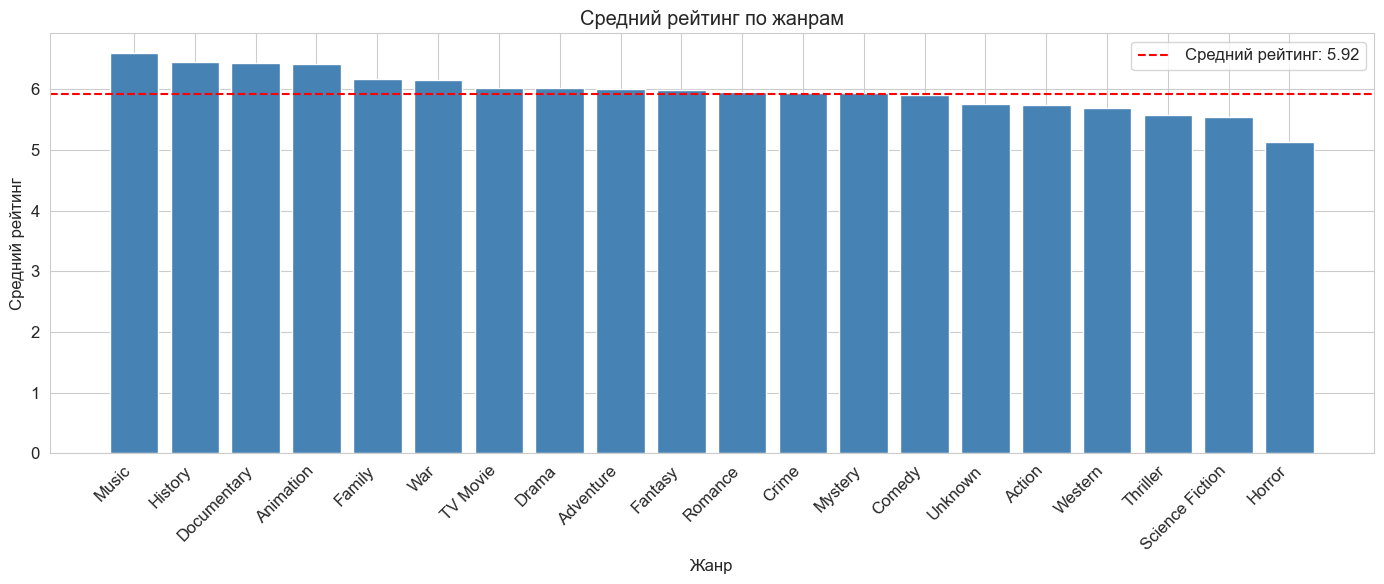

In [16]:
# разбиваем строку жанров на отдельные жанры
genres_expanded = df['genres'].str.split(',').explode().str.strip()
genre_ratings = df.loc[genres_expanded.index, 'vote_average'].groupby(genres_expanded).mean()
genre_counts = genres_expanded.value_counts()

# оставляем жанры с хотя бы 10 фильмами
top_genres = genre_counts[genre_counts >= 10].index
genre_ratings = genre_ratings[top_genres].sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(genre_ratings.index, genre_ratings.values, color='steelblue', edgecolor='white')
plt.axhline(df['vote_average'].mean(), color='red', linestyle='--',
            label=f"Средний рейтинг: {df['vote_average'].mean():.2f}")
plt.title('Средний рейтинг по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(f'{IMG_PATH}03_rating_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Зависимость рейтинга от бюджета

Проверяем гипотезу: бюджет положительно коррелирует с рейтингом.

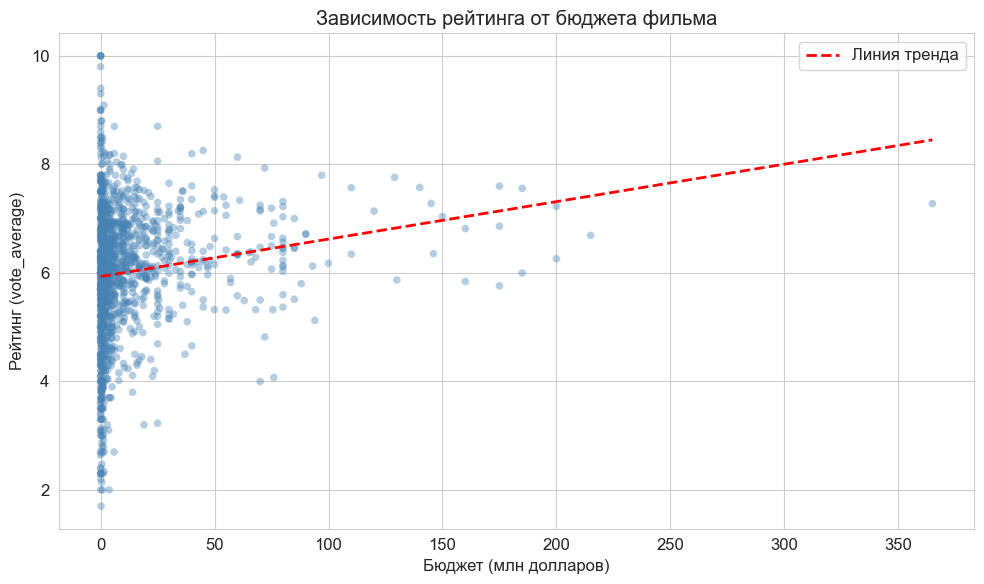

Корреляция Пирсона (бюджет — рейтинг): 0.152


In [17]:
plt.figure(figsize=(10, 6))

# убираем фильмы с нулевым бюджетом для чистоты графика
df_budget = df[df['budget'] > 0]

plt.scatter(df_budget['budget'] / 1e6, df_budget['vote_average'],
            alpha=0.4, color='steelblue', edgecolors='none', s=30)
plt.xlabel('Бюджет (млн долларов)')
plt.ylabel('Рейтинг (vote_average)')
plt.title('Зависимость рейтинга от бюджета фильма')

# линия тренда
z = np.polyfit(df_budget['budget'], df_budget['vote_average'], 1)
p = np.poly1d(z)
x_sorted = np.sort(df_budget['budget'])
plt.plot(x_sorted / 1e6, p(x_sorted), 'r--', linewidth=2, label='Линия тренда')
plt.legend()

plt.tight_layout()
plt.savefig(f'{IMG_PATH}04_budget_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляция Пирсона
corr_val = df_budget['budget'].corr(df_budget['vote_average'])
print(f"Корреляция Пирсона (бюджет — рейтинг): {corr_val:.3f}")

### 4.5 Динамика рейтинга по годам

Анализируем как менялся средний рейтинг фильмов с течением времени.

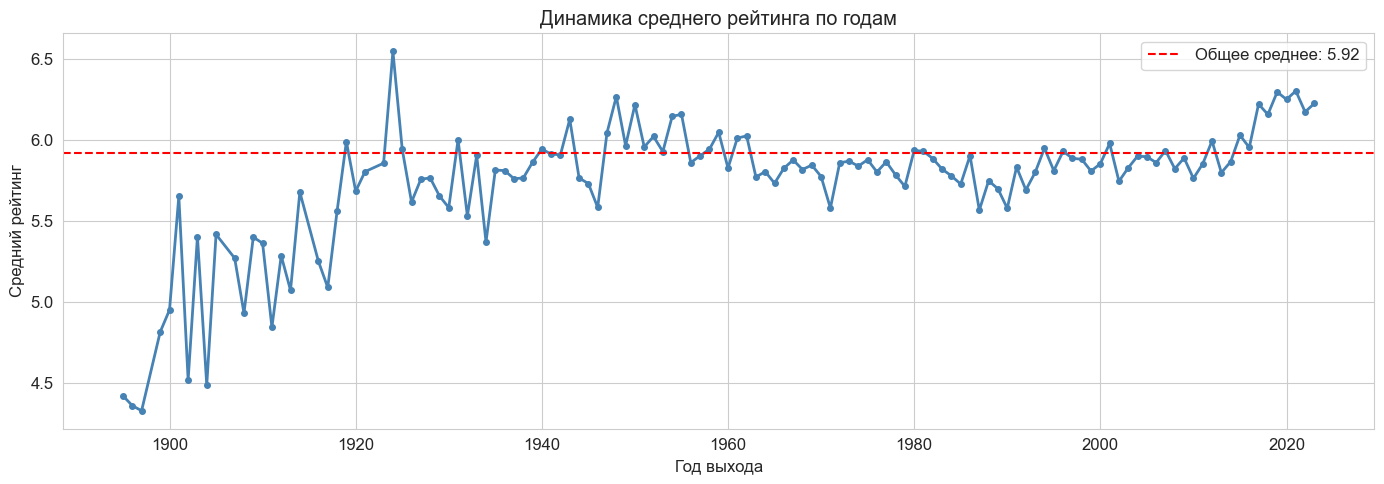

In [20]:
df['release_year'] = pd.to_datetime(df['release_date']).dt.year

# оставляем только годы с достаточным количеством фильмов
year_counts = df['release_year'].value_counts()
valid_years = year_counts[year_counts >= 5].index
df_years = df[df['release_year'].isin(valid_years)]

year_rating = df_years.groupby('release_year')['vote_average'].mean()

plt.figure(figsize=(14, 5))
plt.plot(year_rating.index, year_rating.values, color='steelblue', linewidth=2, marker='o', markersize=4)
plt.axhline(df['vote_average'].mean(), color='red', linestyle='--',
            label=f"Общее среднее: {df['vote_average'].mean():.2f}")
plt.title('Динамика среднего рейтинга по годам')
plt.xlabel('Год выхода')
plt.ylabel('Средний рейтинг')
plt.legend()
plt.tight_layout()
plt.savefig(f'{IMG_PATH}05_rating_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5. Feature Engineering

Создаём новые признаки на основе существующих данных для улучшения качества модели.

### 5.1 Временные признаки и финансовые метрики

In [21]:
# год и месяц выхода
df['release_year'] = pd.to_datetime(df['release_date']).dt.year
df['release_month'] = pd.to_datetime(df['release_date']).dt.month

# прибыль и ROI
df['profit'] = df['revenue'] - df['budget']
df['roi'] = df['profit'] / (df['budget'] + 1)

# англоязычный фильм или нет
df['is_english'] = (df['original_language'] == 'en').astype(int)

print("Новые признаки созданы")
print(df[['release_year', 'release_month', 'profit', 'roi', 'is_english']].head(3))

Новые признаки созданы
    release_year  release_month  profit  roi  is_english
12          1985              1       0  0.0           0
35          2020              8       0  0.0           0
45          2019             12       0  0.0           0


### 5.2 Бинарные признаки жанров

Преобразуем строку жанров в набор бинарных признаков (0/1) для каждого из топ-10 жанров.

In [22]:
top_genres = ['Drama', 'Comedy', 'Action', 'Thriller', 'Horror',
              'Romance', 'Adventure', 'Animation', 'Documentary', 'Music']

for genre in top_genres:
    df[f'is_{genre.lower()}'] = df['genres'].str.contains(genre, na=False).astype(int)

print("Жанровые признаки созданы:")
genre_cols = [f'is_{g.lower()}' for g in top_genres]
print(df[genre_cols].sum().sort_values(ascending=False))

Жанровые признаки созданы:
is_drama          4743
is_comedy         3344
is_thriller       1457
is_documentary    1424
is_romance        1414
is_action         1310
is_horror         1169
is_animation       831
is_adventure       722
is_music           566
dtype: int64


### 5.3 Формирование итогового набора признаков

Определяем матрицу признаков `X` и целевую переменную `y`. Удаляем экстремальные выбросы по `popularity` и `roi` методом перцентилей.

In [24]:
features = [
    'budget', 'revenue', 'runtime', 'popularity', 'vote_count',
    'release_year', 'release_month', 'profit', 'roi', 'is_english',
    'is_drama', 'is_comedy', 'is_action', 'is_thriller', 'is_horror',
    'is_romance', 'is_adventure', 'is_animation', 'is_documentary', 'is_music'
]

# убираем экстремальные выбросы по popularity и roi
Q1_pop = df['popularity'].quantile(0.01)
Q3_pop = df['popularity'].quantile(0.99)
df_clean = df[(df['popularity'] >= Q1_pop) & (df['popularity'] <= Q3_pop)]

Q1_roi = df_clean['roi'].quantile(0.01)
Q3_roi = df_clean['roi'].quantile(0.99)
df_clean = df_clean[(df_clean['roi'] >= Q1_roi) & (df_clean['roi'] <= Q3_roi)]

print(f"Строк после удаления выбросов: {len(df_clean)}")

X = df_clean[features].copy().fillna(0)
y = df_clean['vote_average'].copy()

print(f"Признаков: {X.shape[1]}")
print(f"Объектов: {X.shape[0]}")
print(f"\nЦелевая переменная — vote_average:")
print(f"Мин: {y.min():.2f}, Макс: {y.max():.2f}, Среднее: {y.mean():.2f}")

Строк после удаления выбросов: 11927
Признаков: 20
Объектов: 11927

Целевая переменная — vote_average:
Мин: 0.88, Макс: 10.00, Среднее: 5.91


---

## 6. Кластеризация K-Means

Выявляем естественные группы (сегменты) фильмов в данных без использования целевой переменной.

### 6.1 Масштабирование и подбор числа кластеров

Масштабируем признаки и применяем **метод локтя** для выбора оптимального `k`.

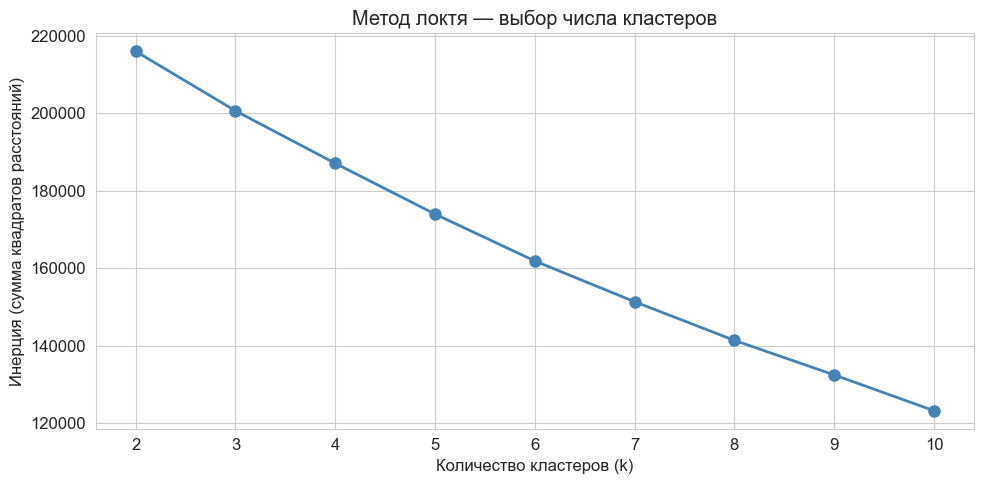

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)

# метод локтя — подбираем оптимальное число кластеров
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Метод локтя — выбор числа кластеров')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (сумма квадратов расстояний)')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}06_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Обучение модели K-Means

Выбираем `k=4` кластера на основе графика метода локтя.

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print("Распределение по кластерам:")
print(df_clean['cluster'].value_counts().sort_index())

Распределение по кластерам:
0      78
1    4513
2    5922
3    1414
Name: cluster, dtype: int64


### 6.3 Визуализация кластеров

Отображаем кластеры в пространстве «популярность — рейтинг».

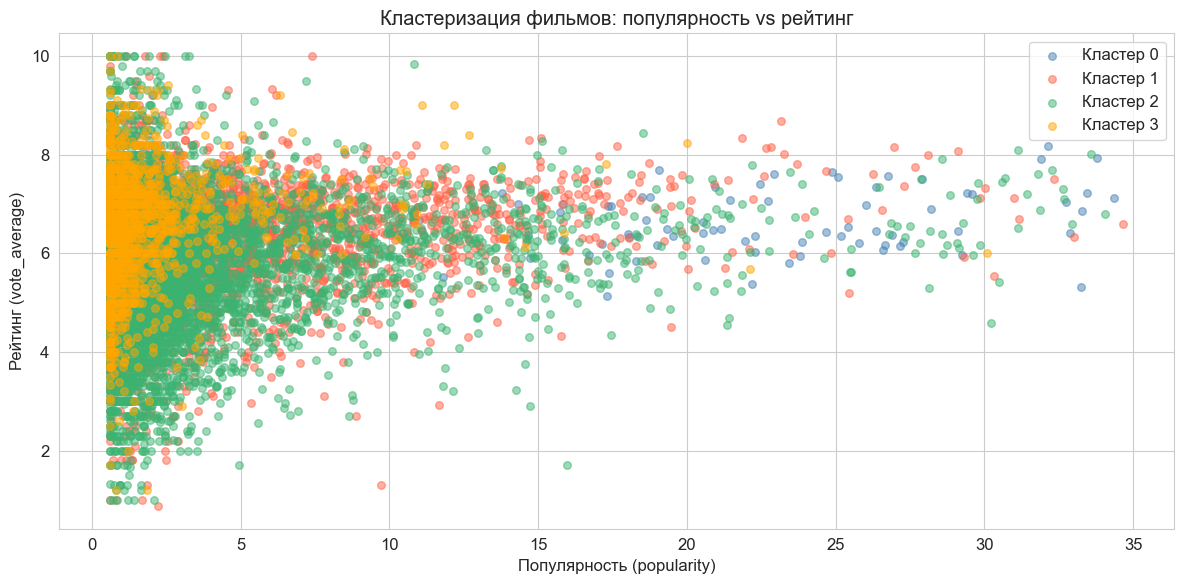

In [27]:
colors = ['steelblue', 'tomato', 'mediumseagreen', 'orange']
cluster_labels = [f'Кластер {i}' for i in range(4)]

plt.figure(figsize=(12, 6))
for i in range(4):
    mask = df_clean['cluster'] == i
    plt.scatter(df_clean.loc[mask, 'popularity'],
                df_clean.loc[mask, 'vote_average'],
                alpha=0.5, s=30, color=colors[i], label=cluster_labels[i])

plt.xlabel('Популярность (popularity)')
plt.ylabel('Рейтинг (vote_average)')
plt.title('Кластеризация фильмов: популярность vs рейтинг')
plt.legend()
plt.tight_layout()
plt.savefig(f'{IMG_PATH}07_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Профиль кластеров

Интерпретируем полученные сегменты по средним значениям ключевых признаков.

In [28]:
cluster_profile = df_clean.groupby('cluster')[
    ['vote_average', 'budget', 'revenue', 'popularity', 'runtime']
].mean().round(2)

cluster_profile.columns = ['Рейтинг', 'Бюджет', 'Сборы', 'Популярность', 'Длительность']
cluster_profile['Кол-во фильмов'] = df_clean['cluster'].value_counts().sort_index()

print("Профиль кластеров:")
print(cluster_profile)

Профиль кластеров:
         Рейтинг       Бюджет         Сборы  Популярность  Длительность  \
cluster                                                                   
0           6.63  59300000.00  2.183740e+08         21.93        114.60   
1           5.99    672485.02  9.978742e+05          3.57         94.53   
2           5.71    584289.82  8.389802e+05          3.30         73.68   
3           6.43     24859.89  8.339954e+04          1.75         71.35   

         Кол-во фильмов  
cluster                  
0                    78  
1                  4513  
2                  5922  
3                  1414  


---

## 7. Регрессионные модели

Обучаем и сравниваем четыре модели машинного обучения для предсказания зрительского рейтинга.

### 7.1 Разбивка на обучающую и тестовую выборки

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка:  {X_test.shape[0]} объектов")

Обучающая выборка: 9541 объектов
Тестовая выборка:  2386 объектов


### 7.2 Вспомогательная функция для расчёта метрик

Используем три метрики: **MAE** (средняя абсолютная ошибка), **RMSE** (среднеквадратичная ошибка), **R²** (коэффициент детерминации).

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R²   = {r2:.4f}")
    print()
    return {'Модель': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)}

### 7.3 Модель 1: Linear Regression

Базовая линейная модель — служит точкой отсчёта для сравнения.

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results = []
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

Linear Regression:
  MAE  = 0.9127
  RMSE = 1.1971
  R²   = 0.1521



### 7.4 Модель 2: Random Forest

Ансамблевая модель на основе множества решающих деревьев.

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

Random Forest:
  MAE  = 0.8639
  RMSE = 1.1465
  R²   = 0.2222



### 7.5 Модель 3: Gradient Boosting

Последовательный ансамбль деревьев с градиентным спуском.

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb))

Gradient Boosting:
  MAE  = 0.8573
  RMSE = 1.1435
  R²   = 0.2263



### 7.6 Модель 4: CatBoost

Градиентный бустинг, оптимизированный для работы с категориальными признаками.

In [34]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(iterations=500, learning_rate=0.05, random_state=42, verbose=0)
cb.fit(X_train, y_train)
y_pred_cb = cb.predict(X_test)

results.append(evaluate_model('CatBoost', y_test, y_pred_cb))

CatBoost:
  MAE  = 0.8380
  RMSE = 1.1278
  R²   = 0.2474



### 7.7 Сравнительная таблица моделей

In [35]:
results_df = pd.DataFrame(results).set_index('Модель')
print("Сравнение моделей:")
print(results_df)

Сравнение моделей:
                      MAE    RMSE      R²
Модель                                   
Linear Regression  0.9127  1.1971  0.1521
Random Forest      0.8639  1.1465  0.2222
Gradient Boosting  0.8573  1.1435  0.2263
CatBoost           0.8380  1.1278  0.2474


---

## 8. Визуализация результатов

### 8.1 Сравнение метрик моделей

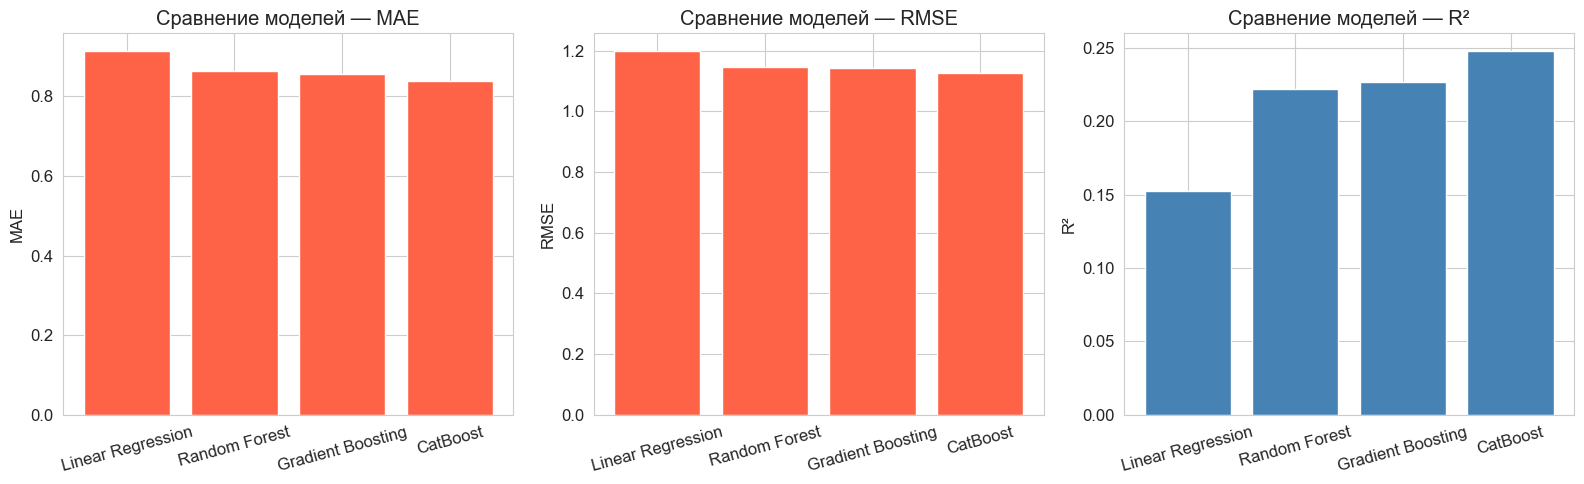

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors = ['tomato', 'tomato', 'steelblue']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], color=colors[i], edgecolor='white')
    axes[i].set_title(f'Сравнение моделей — {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{IMG_PATH}08_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Важность признаков — CatBoost

Определяем какие факторы наиболее значимы для предсказания рейтинга.

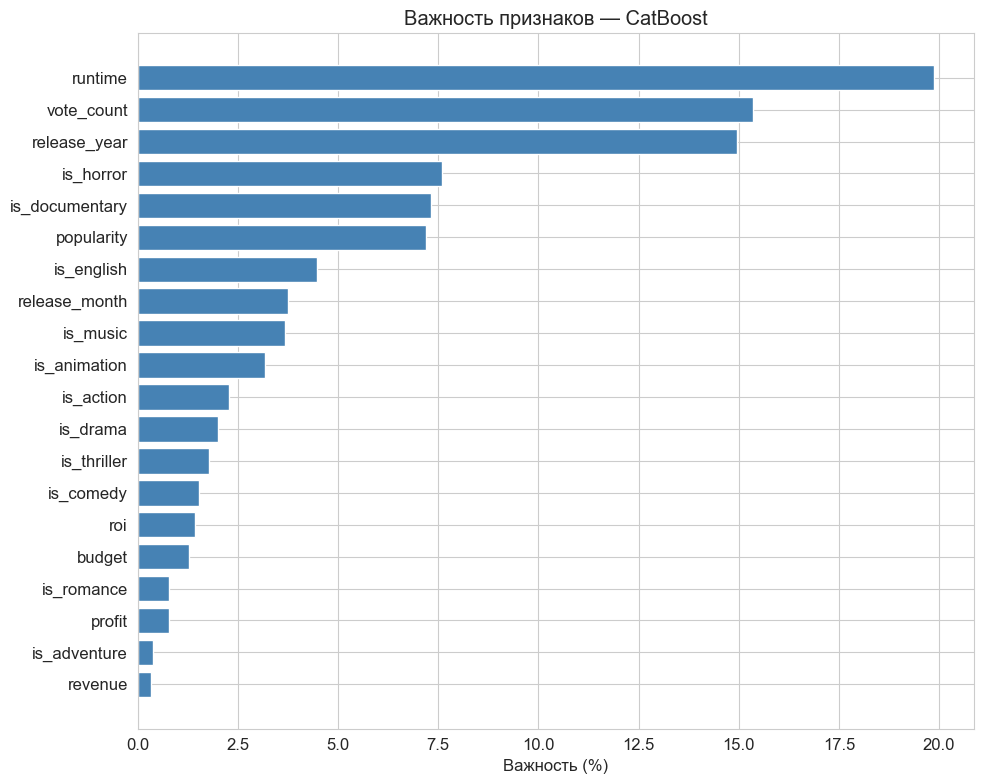


Топ-5 важных признаков:
runtime           19.875893
vote_count        15.355270
release_year      14.959851
is_horror          7.603181
is_documentary     7.326714
dtype: float64


In [37]:
feature_importance = pd.Series(
    cb.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(feature_importance.index, feature_importance.values,
                color='steelblue', edgecolor='white')
plt.title('Важность признаков — CatBoost')
plt.xlabel('Важность (%)')
plt.tight_layout()
plt.savefig(f'{IMG_PATH}09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nТоп-5 важных признаков:")
print(feature_importance.sort_values(ascending=False).head(5))

### 8.3 Реальный vs предсказанный рейтинг

Оцениваем качество предсказаний лучшей модели визуально. Точки близкие к красной линии — точные предсказания.

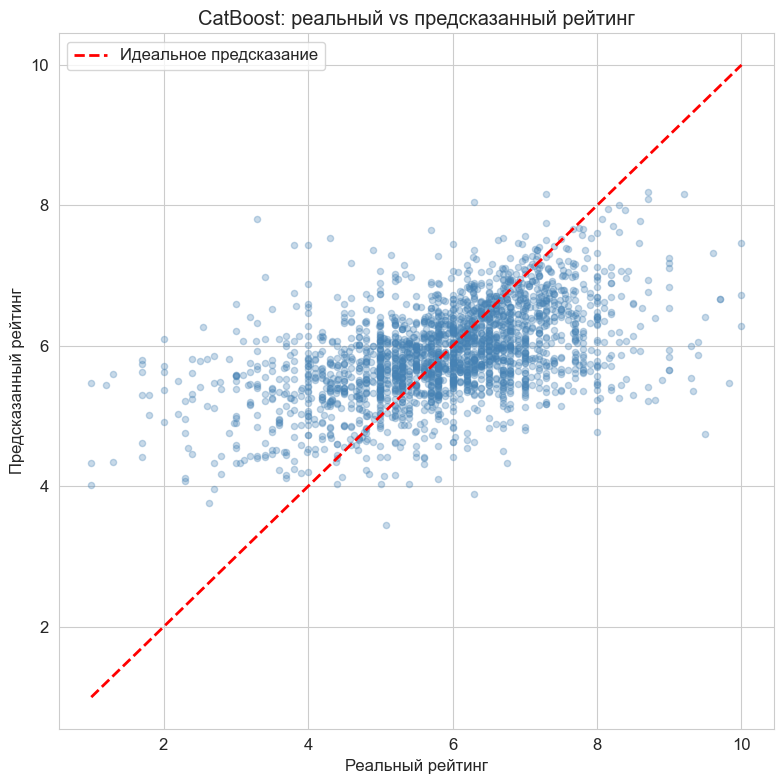

In [38]:
# реальный vs предсказанный рейтинг — CatBoost

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_cb, alpha=0.3, color='steelblue', s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальный рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title('CatBoost: реальный vs предсказанный рейтинг')
plt.legend()
plt.tight_layout()
plt.savefig(f'{IMG_PATH}10_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()